# Building a neural network from scratch with NumPy
This notebook documents the full process of implementing a basic feedforward neural network to classify handwritten digits using the MNIST dataset.

## 1. Introduction
### Why build from scratch?
Modern machine learning frameworks like PyTorch and Tensorflow are incredibly powerful - but they abstract away almost all of the core mathematical operations. While this is ideal for productivity, since neural networks can be built in a few lines of code, it can lead to a shallow understanding of what's actually happening under the hood.

I find I need to take complex ideas apart into their smallest building blocks and rebuild them myself before I truly understand why they work, and can confidently apply that knowledge to new problems. This project is that process: my attempt to lift the hood on neural networks by implementing one from scratch using only NumPy. The goal is simple: if I can't build it myself, then I don't fully understand it.

### Why this format?
Jupyter notebooks allow me to weave together markdown, LaTeX and Python into a singular narrative. This flexibility turns the project into more than just code - it becomes a computational notebook in the truest sense:
- Markdown captures the reasoning and context
- LaTeX allows accurate typesetting of complex mathematical expressions
- Python turns theory into executable code.

This particular format encourages deep thinking and makes the learning process visible - not just the end result. It also aligns with the traditions of science and mathematics, where understanding is often built through annotated derivations, not just final answers.

### Overview of Architecture
The most basic versions of neural networks are known as multi-layer perceptrons, or MLPs.

We will build a MLP with a single hidden layer, as understanding MLPs is somewhat of a pre-requisite to understanding more modern varients of neural networks.
There will be 784 nodes in the input layer, a single hidden layer consisting of 32 nodes (because honestly, that's a nice number that we can easily visualise to see what the network is learning), and an output layer of 10 nodes - one corresponding to each of the 10 possible classes the digits belong to.

## 2. Load and Preprocess MNIST dataset
Yes, I know this comes from Keras, but honestly, this was the fastest way to get the data as a numpy array. The original data is in some obscure binary format. Each image is a 28x28 numpy array.

**Training set:** contains 60,000 images.

**Test set:** contains 10,000 images.

Array: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253

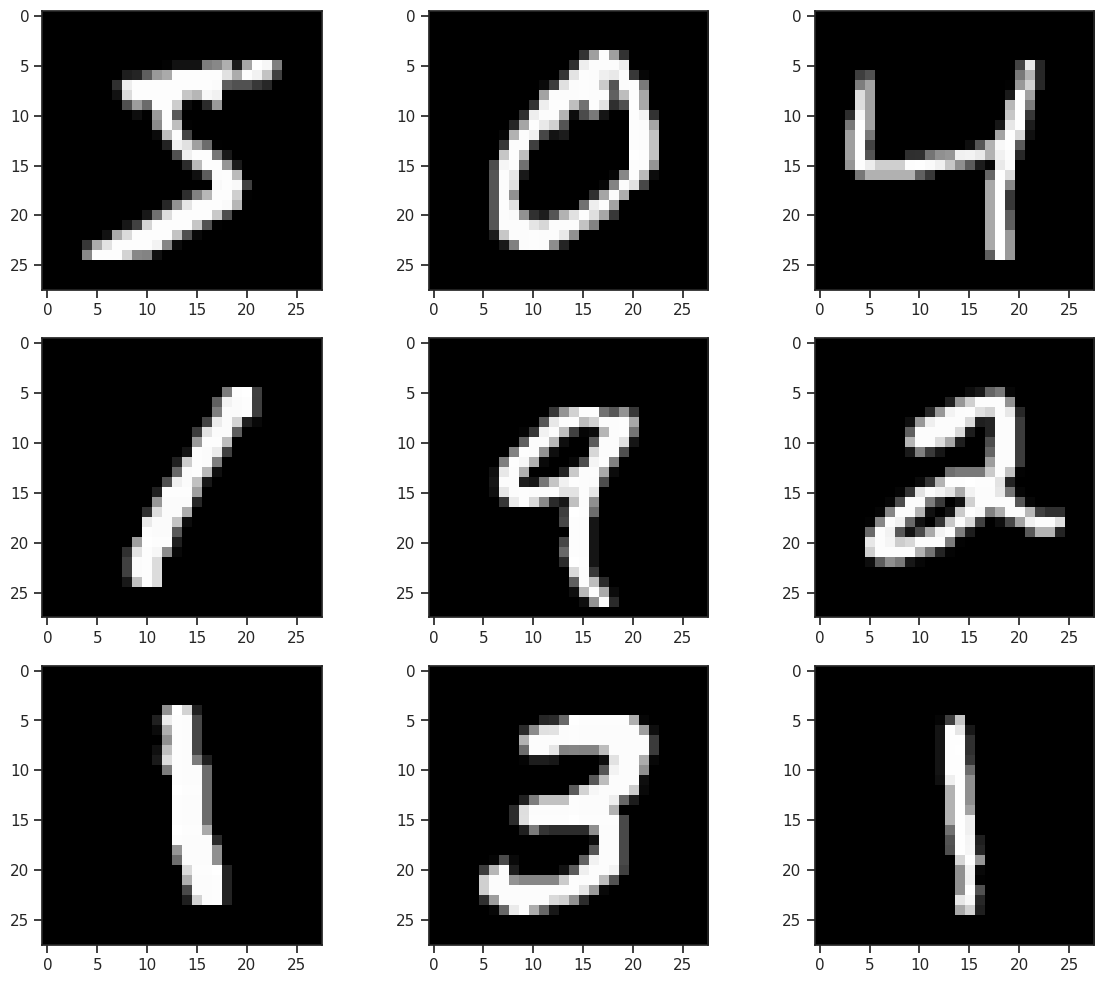

In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
from keras.datasets import mnist
import matplotlib.pyplot as plt
import seaborn as sns

# Control global appearance of figures etc.
sns.set_theme(context="notebook", style="ticks", palette="viridis")

# Import and visualise the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f'Array: {X_train[0]}')
print(f'Training Label: {y_train[0]}')

#Plot the first 9 images in the data set
fig, ax = plt.subplots(3,3)
fig.set_size_inches(12, 10)
k = 0
for i in range(3):
    for j in range(3):
        ax[i,j].imshow(X_train[k].reshape(28, 28), cmap="gray")
        k += 1
plt.tight_layout()


Firstly, we need to normalise the dataset. Currently, the arrays for the images are between 0 (completely black pixel) and 255 (completely white pixel). However, neural networks really, _really_ like inputs to be between 0 and 1. Easiest way to do this: simply divide every value in the array by 255.

Next, squash the array for each image to a 1-dimensional vector. These 1D vectors are much faster to calculate than a 28x28 matrix. This will give a 1D vector of 784 columns (28x28 = 784) for each image. The training set should then be an array of 60000 rows and 784 columns, and the  test set 1000 rows and also 784 columns. The labels are already a 1D array and do not need reshaping here.

In [2]:
# Normalise the data
X_train = X_train/255
X_test = X_test/255

print(f'Normalised Array: {X_train[0]}')

# Flatten X_train and X_test to 1 dimension, then confirm we have done so using .shape method
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')

Normalised Array: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
 

Finally, One-hot encode the labels, and convert them from ["6, 9, 4, 3"] to strings of ones and zeros representing the number.

**Remember:** Python indexes from zero, not one. So the array is 0-9, not 1-9, and then 0.

In [3]:
# One Hot encode the image labels
# Code shamelessly borrowed from: https://stackoverflow.com/questions/29831489/convert-array-of-indices-to-one-hot-encoded-array-in-numpy

n_values = np.max(y_train) + 1
y_train_encoded = np.eye(n_values)[y_train]
n_values = np.max(y_test) + 1
y_test_encoded = np.eye(n_values)[y_test]

print(y_train_encoded.shape)

# Select a random image from the training and test set and print the original label and encoded label to confirm this has worked.
print(f'Original label: {y_train[42]}\nEncoded label: {y_train_encoded[42]}')
print(f'Original label: {y_test[42]}\nEncoded label: {y_test_encoded[42]}')

(60000, 10)
Original label: 7
Encoded label: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Original label: 4
Encoded label: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


Now, each image is a 784-dimensional vector, normalised so each value within the vector is between 0 and 1. Each image label has been One-hot encoded so that it is a 10-dimensional vector and we have a test and train set. The data is now ready to be passed through the neural network.

#### 📚 Side Quest: How might we reshape the array using np.ndarray.flatten?
TODO: what does np.ndarray.flatten actually do?

x.flatten() flattens each individual sample into a 1D array.
Wrapping with np.array([...]) reconstructs a 2D array: shape becomes (num_samples, features_per_sample)

In [4]:
#X_test = np.array([x.flatten() for x in X_test])
#print(f'Shape of X_test: {X_test.shape}')

## 3. Define Core Components of the Neural Network
There are many frequently used components in neural networks. These include: dense (fully connected) layers, a number of activation functions like reLU, Sigmoid and Softmax, loss functions and a number of different optimisation methods like Stochastic Gradient Descent (SDG) and Adam.

### Dense (fully connected) layers
When all the neurons in a layer are connected to every neuron in the previous layer _i.e.,_ the input neurons, this is called a dense or fully connected layer.

### Activation functions (ReLU, Sigmoid, Softmax)
#### Why do we need activation functions?
Activation functions are necessary, because if we chain several linear transformations together, all you get out is another linear transformation. Essentially, without the nonlinearity introduced between layers by the activation functions, then even a stack of 100 layers is effecively equivalent to a single layer, and you can't solve very complex problems with that.

**Sigmoid** - very negative inputs end up close to zero, positive inputs are close to 1.

**ReLU** - Rectified linear unit. This function is not differentiable at z=0, as the gradient changes abruptly, which can make Gradient Descent bounce around. However, it is fast to compute, considered to be easier to train than Sigmoid functions, and therefore learn faster. So this is often the default activation function used within neural networks.  

**tanh** - Hyperbolic tan function. Just like the sigmoid function, this function is also s-shaped, continuous and differentiable, but it's output ranges from -1 to 1. This range tends to make each layers output more or less centered around 0 at the beginning of training, which often helps speed up convergence.

**Softmax** - Useful in multiclass classification problems as it ensures that all the estimated probabilities are between 0 and 1 and that they all add up to 1, which is needed if the classes are exclusive _i.e.,_ that an input can only belong to a single class.

**Activation Functions**

$$
\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}  
$$
$$
\text{ReLU}(x) = \max(0, x)  
$$
$$
\text{softmax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}  
$$
$$
\tanh(x) = 2\sigma(2x) - 1
$$

### Loss function (cross-entropy)
Cross entropy loss (also called the log loss) is a popular loss function to measure the performance of a classification model. It measures the difference between the probability distribution function predicted by the model and the true values.

The cross-entropy loss function is used to find the optimal solution by adjusting the weights of the neural network during training, to minimise the difference between the output of the model and the true values. A lower loss value indicates the model is more successful.

### Optimisation (Adam, SDG)
Optimisation algorithms are used to minimise a loss function, that represents how far a models predictions are from the true values. The main goal is (in this context) to adjust the weights and biases of the model to minimise the error. Many different types of optimisation functions can be used including Gradient Descent, Stochastic Gradient Descent and Adam (Adaptive Moment Estimation). Here, we will choose the simplest of these to implement in Numpy - Gradient Descent.

### Accuracy metric
The accuracy metric for this neural network is accuracy. This is a measure of the number of correctly identified images, divided by the total number of images in the set.

**Functions for Cross entropy loss**
 $$ -\sum_{c=1}^{N}y_{c} log(p_{c})$$

**Optimisation**
$$ \theta = \theta - \eta \nabla_{\theta}J(\theta) $$

**Accuracy**

$$ accuracy = \frac{correct}{total}*100 $$



In [5]:
# Define activation functions in python
def sigmoid(Z):
    """Sigmoid activation function. Maps input values to a range between 0 and 1.

    Args:
        Z (np.ndarray): Input array or scalar.

    Returns:
        np.ndarray: Output after applying the sigmoid function element-wise.
        """
    return 1/(1 + np.exp(-Z))

def relu(Z):
    """ReLU (Rectified Linear Unit) activation function. Applies the function f(x) = max(0, x) element-wise.

    Args:
        Z (np.ndarray): Input array or scalar.

    Returns:
        np.ndarray: Output after applying ReLU element-wise.
    """
    return np.maximum(0,Z)

def softmax(Z):
    """Numerically stable softmax activation function. Converts logits to probabilities by exponentiating input values
        after subtracting the maximum to improve numerical stability.

        Args:
            Z (np.ndarray): Input array of shape (batch_size, num_classes)
                            or any shape where softmax is applied along the last axis.

        Returns:
            np.ndarray: Probability distribution with the same shape as input,
                        where values sum to 1 along the softmax axis.
        """
    exps = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exps / np.sum(exps, axis=0, keepdims=True)

#### 📚 Side Quest: Plot Activation functions so we can see what they look like.
Plotting activation functions serves two purposes: allows us to develop a feel for how the function behaves across a range of input values, it makes it immediately clear why reLU is better for deep networks (it avoids saturation) and how sigmoid squashifies the values between 0 and 1; it also enables us to verify we've implemented the functions correctly in numpy. This is useful because we have none of debugging tools in Tensorflow/ Pytorch at our disposal.

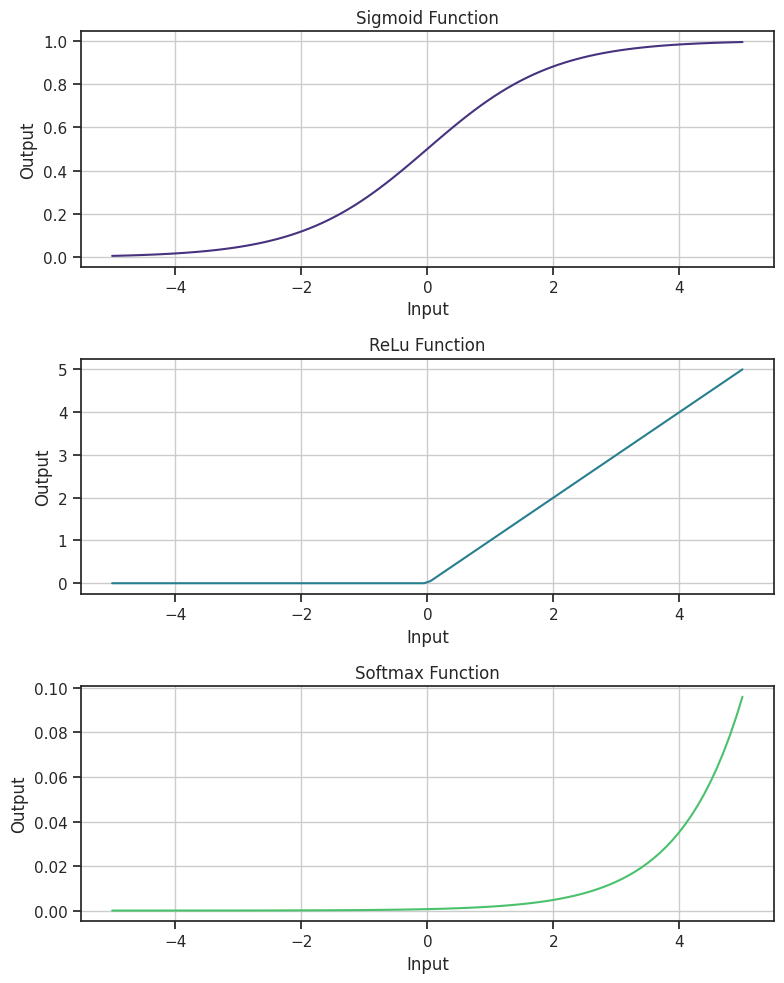

In [6]:
# Generate input values
x = np.linspace(-5, 5, 100)

# Compute activation values
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_softmax = softmax(x)

# Create the plot
fig, axes = plt.subplots(3,1, figsize=(8,10))

axes[0].plot(x, y_sigmoid, color=sns.color_palette("viridis")[0])
axes[0].set_title("Sigmoid Function")
axes[0].set_xlabel("Input")
axes[0].set_ylabel("Output")
axes[0].grid(True)

axes[1].plot(x, y_relu, color=sns.color_palette("viridis")[2])
axes[1].set_title("ReLu Function")
axes[1].set_xlabel("Input")
axes[1].set_ylabel("Output")
axes[1].grid(True)

axes[2].plot(x, y_softmax, color=sns.color_palette("viridis")[4])
axes[2].set_title("Softmax Function")
axes[2].set_xlabel("Input")
axes[2].set_ylabel("Output")
axes[2].grid(True)

# Formatting
plt.tight_layout()
plt.show()

#### 📚 Side Quest: What is the vanishing gradient problem?
This is the problem of very different magnitudes in terms of the gradients between layers, encountered when training neural networks through backpropagation. When using backpropagation, neural network weights are updated proprtional to their partial derivative of the loss function.  The deeper the network, the more likely this issue is to arise, and introduces instability into the training process, or may slow or stop it entirely.

Can be solved using batch normalisation - this also would solve the exploding gradient problem. Rectified activation functions like ReLU seem to suffer less with the vanishing gradient problem, and thus allow deeper networks to be trained than sigmoid or tanh would.

#### 📚 Side Quest: What is the difference between Softmax and safe Softmax?
Why might we use one over the other?

## 4. Forward Propagation
### What is forward propagation?
Forward propagation is the process where a neural network transforms input data into predictions or outputs. Forward propagation is how the network processes that information through its layers to produce a result. It's the sequential calculation that transforms the input data through weighed connections between nodes and activation functions, allowing the network to capture complex patterns.



#### 📚 Side Quest - Visualise the neural network itself.
This plot does display the overall architecture of the network, but does not show all of the nodes involved in the network. It does, however show how every layer (except the input layer) recieves a pre-activation input (purple) and following the application of an activation function, gives an output (green) and this - alongside the weights and biases of the edges of the network - becomes the input for the next layer.

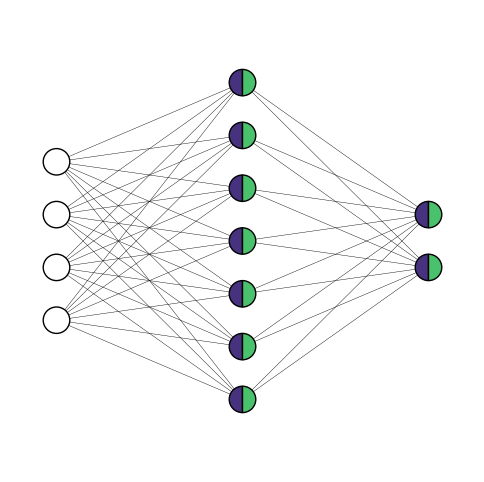

In [7]:
# Code borrowed from https://gist.github.com/craffel/2d727968c3aaebd10359 and https://stackoverflow.com/questions/67279657/drawing-a-neural-network
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge

def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    '''
    Draw a neural network cartoon using matplotilb.

    :usage:
        >>> fig = plt.figure(figsize=(12, 12))
        >>> draw_neural_net(fig.gca(), .1, .9, .1, .9, [4, 7, 2])

    :parameters:
        - ax : matplotlib.axes.AxesSubplot
            The axes on which to plot the cartoon (get e.g. by plt.gca())
        - left : float
            The center of the leftmost node(s) will be placed here
        - right : float
            The center of the rightmost node(s) will be placed here
        - bottom : float
            The center of the bottommost node(s) will be placed here
        - top : float
            The center of the topmost node(s) will be placed here
        - layer_sizes : list of int
            List of layer sizes, including input and output dimensionality
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)
    # Nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2. + (top + bottom) / 2.

        for m in range(layer_size):
            center = (n * h_spacing + left, layer_top - m * v_spacing)
            radius = v_spacing / 4.

            if n > 0:
                # Hidden Layers
                wedge_left = Wedge(center, r=radius, theta1=90, theta2=270, color='w', fc=sns.color_palette("viridis")[0], ec='k', zorder=4)
                wedge_right = Wedge(center, r=radius, theta1=270, theta2=90, color='w', fc=sns.color_palette("viridis")[4], ec='k', zorder=4)

                ax.add_artist(wedge_left)
                ax.add_artist(wedge_right)
            else:
                # None hidden layers
                circle = plt.Circle(center, radius, color='w', ec='k', zorder=4)
                ax.add_artist(circle)
    # Edges
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([n*h_spacing + left, (n + 1)*h_spacing + left],
                                  [layer_top_a - m*v_spacing, layer_top_b - o*v_spacing], c='k', linewidth=0.3)
                ax.add_artist(line)

fig = plt.figure(figsize=(6, 6))
ax = fig.gca()
ax.axis('off')
draw_neural_net(ax, .1, .9, .1, .9, [4, 7, 2])
#fig.savefig('nn.png')

### Forward Propagation
Let's define some things before I get horribly muddled.

The input layer to a neural network has **no associated activation function**. Therefore, the pre-activation input, and the 'activated' version of the input layer are identical  

**Input layer:** (could probably also call this $A^{[0]}$)
$$
\text{Input layer} = X$$


**First hidden layer (pre-activation "input"):**
$$
Z^{[1]} = X.(W^{[1]})^{T}+B^{[1]}
$$

**First hidden layer (output):**
$$
A^{[1]} = ReLU(Z^{[1]})
$$

**Output layer (pre-activation "input")**
$$
Z^{[2]} = A^{[1]}.(W^{[2]})^{T}+B^{[2]}
$$
**Output layer (output):**
$$
A^{[2]} = \text{softmax}(Z^{[2]})
$$

In [8]:
# Now lets turn all that maths into python code
def init_params():
    """Initialises the weights and biases for the network as arrays of random floats between -0.5 and 0.5

    Args:
        none

    Returns:
        W1: (np.ndarray) an array of shape 32x784, representing the initial weights of the first layer.
        B1: (np.ndarray) an array of shape 32x1, representing the initial biases of the connections of the first layer.
        W2: (np.ndarray) an array of shape 10x32, representing the initial weights of the second layer of the network.
        B2: (np.ndarray) an array of shape 10x1, representing the initial biases of the connections of the second layer.

    """
    # For reproducibility
    np.random.seed(42)

    params = {}

    params['W1'] = np.random.rand(32, 784)-0.5
    params['B1'] = np.random.rand(32, 1)-0.5
    params['W2'] = np.random.rand(10, 32)-0.5
    params['B2'] = np.random.rand(10, 1)-0.5

    return params

def forward_prop(params, X):
    """ Performs forward propagation through the network.

    Args:
    X: (np.ndarray) an array of shape 728xm representing the input data (train or test set)
    params: (np.ndarray) a series of arrays representing the weighs and biases of the network

    Returns:
    cache_values: (dict) a dictionary of arrays holding the inputs for each node pre and post activation
    A2: (np.ndarray) Output of the network

    """
    cache_values = {}

    # Input layer has no activation function. The input is the output.
    A0 = X.T
    cache_values['A0'] = A0

    # First hidden layer

    Z1 = np.dot(params['W1'], A0)+ params['B1']

    # Apply activation function
    A1 = relu(Z1)

    # Store values for backprop later
    cache_values['Z1'] = Z1
    cache_values['A1'] = A1

    # Output layer - get params
    W2 = params['W2']
    B2 = params['B2']

    Z2 = np.dot(W2, A1)+B2

    # Apply activation function
    A2 = softmax(Z2)

    # Store output layer values
    cache_values['Z2'] = Z2
    cache_values['A2'] = A2

    return cache_values, A2

In [9]:
# Run the forward propagation
params = init_params()
cache_values, output = forward_prop(params, X_train)

# Sense check: Print the first image and confirm this matches the normalised array from earlier. It does!!
#print(cache['A0'][0])

# Neural network, how certain are you about your predictions? Apparently not very?
print(output[:,0])

# Compute accuracy following the first round of forward propagation.
true_labels = y_train.T
predictions = np.argmax(output, axis=0)
accuracy = np.mean(predictions == true_labels)*100

print(f"Accuracy: {accuracy:.2f}")

[0.02837636 0.15943175 0.00255224 0.11161987 0.03905605 0.0022502
 0.0101368  0.35529124 0.2867838  0.00450169]
Accuracy: 10.35


### Analysis of forward propagation
Oh dear. The neural network following a single round of forward propagation has a 10.35% accuracy. This is expected, as we're initialising the weights and biases for the neural network with random numbers. Growth mindset little neural network!!

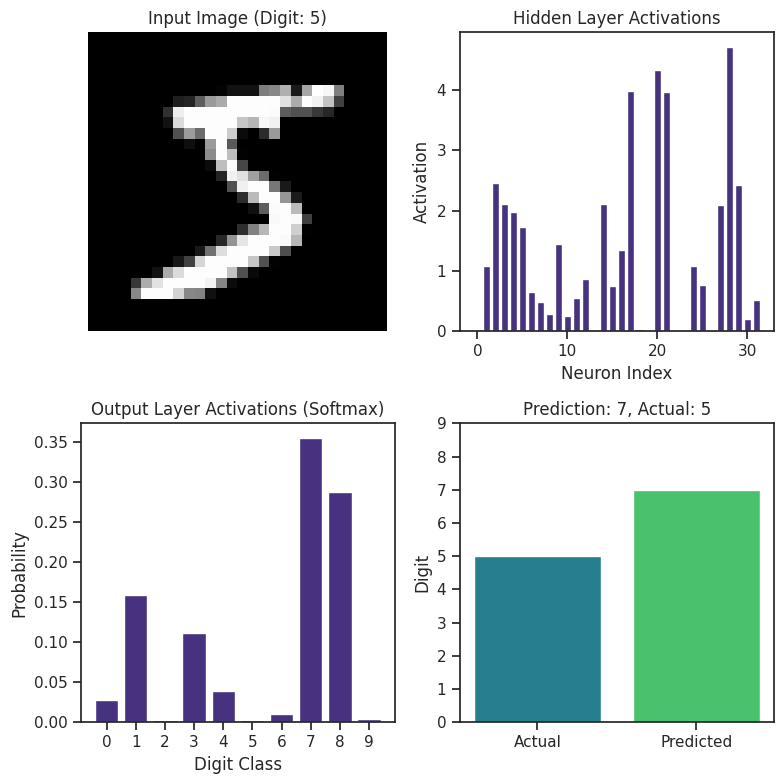

In [10]:
# Let's visualise the activations of the neurons.
def visualize_network_processing(image, label, cache_values):
   """Visualize network processing for a single image"""
   plt.figure(figsize=(8, 8))

   # Plot original image
   plt.subplot(2,2,1)
   plt.imshow(image.reshape(28, 28), cmap='gray')
   plt.title(f"Input Image (Digit: {label})")
   plt.axis('off')

   # Plot hidden layer activations (first 50 neurons)
   plt.subplot(2,2,2)
   hidden_activations = cache_values['A1'][:32, 0]
   plt.bar(range(len(hidden_activations)), hidden_activations)
   plt.title("Hidden Layer Activations")
   plt.xlabel("Neuron Index")
   plt.ylabel("Activation")

   # Plot output layer activations
   plt.subplot(2,2,3)
   output_activations = cache_values['A2'][:, 0]
   plt.bar(range(10), output_activations)
   plt.xticks(range(10))
   plt.title("Output Layer Activations (Softmax)")
   plt.xlabel("Digit Class")
   plt.ylabel("Probability")

   # Plot prediction vs actual
   plt.subplot(2,2,4)
   prediction = np.argmax(output_activations)
   plt.bar(['Actual', 'Predicted'], [label, prediction], color =[sns.color_palette("viridis")[2], sns.color_palette("viridis")[4]])
   plt.title(f"Prediction: {prediction}, Actual: {label}")
   plt.ylabel("Digit")
   plt.ylim(0,9)
   plt.tight_layout()
   plt.show()

# Visualize forward propagation for the first image in our batch
image_idx = 0
image= X_train[image_idx]
label = true_labels[image_idx]

visualize_network_processing(image, label, cache_values)

We have now passed the training set through the network for the first time, observed the activation values of both the hidden and output layers and began to investigate the predictions made by the network. However, the predictions aren't very good - currently the neural network is no more accurate than simply randomly guessing. So we need to teach the network what the answers really are in some way.

## 5. Backward Propagation
Introduced in the 1970's, the backpropagation algorithm is the method for fine-tuning the weights of a neural network with respect to the error rate obtained in the previous iteration (or epoch), In short, backward propagation is how a neural network learns.

Following a round of training, the network 'reviews' its performance. It calculates the error between its output and the correct answer, then adjusts the weights of the edges in the network, to try and reduce the error next time.

Backward propagation has four main steps:
- Forward pass (forward propagation)
- Error calculation
- Backward pass (backward propagation)
- Update weights and biases

**Error calculation**
$$ dZ^{[2]} = A^{[2]} - Y.T $$

**Backward propagation**
$$ dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T} $$
$$ dB^{[2]} = \frac{1}{m} \Sigma {dZ^{[2]}} $$
$$ dZ^{[1]} = W^{[2]T} .dZ^{[2]}* g^{[1]\prime} (z^{[1]}) $$
$$ dW[1]=\frac{1}{m}dZ^{[1]} A^{[0]T} $$
$$ dB^{[1]} = \frac{1}{m} \Sigma {dZ^{[1]}}$$

**Update weights**
$$ W^{[2]} = W^{[2]} - \alpha dW^{[2]}$$
$$ B^{[2]} = B^{[2]} - \alpha dB^{[2]}$$
$$ W^{[1]} = W^{[1]} - \alpha dW^{[1]}$$
$$ B^{[1]} = B^{[1]} - \alpha dB^{[1]}$$


In [11]:
# Again, turn all that maths into python code.

def deriv_relu(X):
    """ Derivative of the ReLU function """
    return X > 0

# Error Calculation
def cross_entropy_loss(cache_values, Y):
    """
    Compute the cross-entropy loss for softmax output.

    Args:
        cache_values:(dict) Dictionary containing forward pass values, including 'A2'.
            'A2' should have shape (n_classes, n_samples) — softmax probabilities.
        Y: (ndarray)One-hot encoded true labels, shape (n_samples, n_classes).

    Returns:
        float: Mean cross-entropy loss over all samples.
    """
    m = Y.shape[0]  # number of samples
    probs = cache_values['A2'].T  # shape (n_samples, n_classes)
    loss = -np.sum(Y * np.log(probs + 1e-15)) / m
    return loss

def cross_entropy_loss_grad(cache_values, Y):
    """Compute the gradient of the cross-entropy loss w.r.t. the logits for softmax output."""
    network_error = cache_values['A2'] - Y.T
    return network_error

# Calculate gradients through backpropagation
def backward_prop(Y, network_error, cache_values, params):
    """ Performs backward propagation through the network
    Args:
      Y: True labels
      network_error: (np.ndarray) Error between predicted and true values
      cache_values: (np.ndarray) Values of each node pre- and post activation
      params: Weights and biases of the network

    Returns:
      gradients:


    """
    m = Y.shape[1]
    A0 = cache_values['A0']
    A1 = cache_values['A1']
    Z1 = cache_values['Z1']

    gradients= {}

    # Second layer (output)
    dZ2 = cross_entropy_loss_grad(cache_values, Y)
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    dB2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    # Store values
    gradients['dZ2'] = dZ2
    gradients['dW2'] = dW2
    gradients['dB2'] = dB2

    # Hidden layer
    dZ1 = np.dot(params['W2'].T, dZ2) * deriv_relu(Z1)
    dW1 = (1 / m) * np.dot(dZ1, A0.T)
    dB1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    # Store values
    gradients['dZ1'] = dZ1
    gradients['dW1'] = dW1
    gradients['dB1'] = dB1
    return gradients

# Update weights and biases
def update_params(params, gradients, alpha):
    """Updates the weights and biases of the network using gradients and the learning rate.
        Args:
          params: weights and biases of the network
          gradients: gradients as determined by backwards propagation
          alpha: (float) learning rate
        Returns:
          params: updated weights and biases of the network
        """

    params['W1'] = params['W1'] - (alpha * gradients['dW1'])
    params['B1'] = params['B1'] - (alpha * gradients['dB1'])
    params['W2'] = params['W2'] - (alpha * gradients['dW2'])
    params['B2'] = params['B2'] - (alpha * gradients['dB2'])
    return params

## 6. Training Loop
The training loop is the core engine of the neural network. This is where forward propagation happens, the loss is claculated, backpropagation computes the gradients and the weights and biases are updated.

In addition to training the model, we also want to: track the loss (how wrong the model is i.e., the error between what the model thinks the answer is, and the true label for each image), track the accuracy on the training set and plot both as a function of time to visualise the learning process.

This helps us answer: is the network learning, is it under or overfitting the data and are the hyperparameters (learning rate) sensible.  

In [12]:
def gradient_descent(X, Y, params, epochs, alpha):
  """ Undertakes the full training loop
      args:
        X:
        Y: (np.ndarray)
        params: (dict) weights and biases of the network
        epochs: (int) number of training epochs
        alpha: (float) learning rate
      returns:
        output:
        params:
        losses: (list) loss of the network per training epoch
        accuracies: (list) accuracy of the network per training epoch"""

  # Lists to store loss and accuracy per epoch
  losses = []
  accuracies = []

  for i in range(epochs):
      cache_values, output = forward_prop(params, X)
      network_error = cross_entropy_loss_grad(cache_values, Y)
      gradients = backward_prop(Y, network_error, cache_values, params)
      params = update_params(params, gradients, alpha)

      predictions = np.argmax(output, axis=0)
      true_labels = np.argmax(Y, axis=1)
      accuracy = np.mean(predictions == true_labels) * 100
      accuracies.append(accuracy)
      loss = cross_entropy_loss(cache_values,Y)
      losses.append(loss)

      if i % 10 == 0 or i==149:
          print(f'After {i+1} epochs - Accuracy: {accuracy:.2f}% | Loss: {loss:.2f}')
  return output, params, losses, accuracies

# Trial full gradient descent.
params = init_params()
print(f'Learning rate: 0.005')
output, params, losses, accuracies = gradient_descent(X_train, y_train_encoded, params, epochs=60, alpha=0.005)

params = init_params()
print(f'Learning rate: 0.001')
output, params, losses, accuracies  = gradient_descent(X_train, y_train_encoded, params, epochs=60, alpha=0.001)


Learning rate: 0.005
After 1 epochs - Accuracy: 10.35% | Loss: 5.06
After 11 epochs - Accuracy: 11.24% | Loss: 3.03
After 21 epochs - Accuracy: 11.24% | Loss: 2.74
After 31 epochs - Accuracy: 9.03% | Loss: 2.76
After 41 epochs - Accuracy: 9.04% | Loss: 2.73
After 51 epochs - Accuracy: 9.76% | Loss: 2.86
Learning rate: 0.001
After 1 epochs - Accuracy: 10.35% | Loss: 5.06
After 11 epochs - Accuracy: 11.29% | Loss: 2.33
After 21 epochs - Accuracy: 11.38% | Loss: 2.30
After 31 epochs - Accuracy: 11.61% | Loss: 2.30
After 41 epochs - Accuracy: 11.53% | Loss: 2.30
After 51 epochs - Accuracy: 11.25% | Loss: 2.31


### Debug:
Hmm. Trialled 0.005 and 0.001 as learning rate, and the network almost seems to not actually be learning? Maybe we need to run hyperparameter tuning on the network to find the right/ better learning rate? Using Optuna as it employs a much more efficient algorithm (Tree-structured Parzen Estimator) than random/ grid search uses.

In [15]:
!pip install optuna
import optuna
from sklearn.model_selection import train_test_split

# Split training into training and validation sets
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train_encoded, test_size=0.1, random_state=42
)

def optuna_objective(trial):
    """
    Objective function for Optuna to tune the learning rate.

    Args:
        trial: An Optuna trial object.

    Returns:
        float: Validation accuracy.
    """
    # Suggest a learning rate (log scale for wide range search)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)

    # Initialize parameters for this trial
    params = init_params()

    # Train the network
    _, trained_params, _, _ = gradient_descent(
        X_train_sub, y_train_sub, params, epochs=100, alpha=lr
    )

    # Forward pass on validation set
    _, output_val = forward_prop(trained_params, X_val)
    predictions = np.argmax(output_val, axis=0)
    true_labels = np.argmax(y_val, axis=1)

    # Calculate validation accuracy
    accuracy = np.mean(predictions == true_labels)

    return accuracy  # Optuna will try to maximize this

# Run Optuna optimization
study = optuna.create_study(direction="maximize")
study.optimize(optuna_objective, n_trials=25)

# Print results
print("Best learning rate:", study.best_params["learning_rate"])
print("Best validation accuracy:", study.best_value)

[I 2025-08-10 13:20:55,172] A new study created in memory with name: no-name-a07e9d9e-3ed8-4be9-9a93-49614a08fe66


After 1 epochs - Accuracy: 10.34% | Loss: 5.06
After 11 epochs - Accuracy: 9.74% | Loss: 17.55
After 21 epochs - Accuracy: 9.75% | Loss: 23.60
After 31 epochs - Accuracy: 9.75% | Loss: 22.63
After 41 epochs - Accuracy: 9.81% | Loss: 24.57
After 51 epochs - Accuracy: 11.27% | Loss: 21.18
After 61 epochs - Accuracy: 10.43% | Loss: 17.75
After 71 epochs - Accuracy: 9.75% | Loss: 21.16
After 81 epochs - Accuracy: 10.43% | Loss: 20.03
After 91 epochs - Accuracy: 10.43% | Loss: 26.79


[I 2025-08-10 13:21:39,672] Trial 0 finished with value: 0.09666666666666666 and parameters: {'learning_rate': 0.015404951809969267}. Best is trial 0 with value: 0.09666666666666666.


After 1 epochs - Accuracy: 10.34% | Loss: 5.06
After 11 epochs - Accuracy: 9.02% | Loss: 28.42
After 21 epochs - Accuracy: 9.81% | Loss: 24.36
After 31 epochs - Accuracy: 11.27% | Loss: 25.55
After 41 epochs - Accuracy: 11.27% | Loss: 28.47
After 51 epochs - Accuracy: 9.02% | Loss: 26.20
After 61 epochs - Accuracy: 9.02% | Loss: 21.93
After 71 epochs - Accuracy: 11.27% | Loss: 24.25
After 81 epochs - Accuracy: 11.27% | Loss: 29.04
After 91 epochs - Accuracy: 9.89% | Loss: 29.79


[I 2025-08-10 13:22:23,827] Trial 1 finished with value: 0.09666666666666666 and parameters: {'learning_rate': 0.030484912643333157}. Best is trial 0 with value: 0.09666666666666666.


...

After 1 epochs - Accuracy: 10.34% | Loss: 5.06
After 11 epochs - Accuracy: 26.89% | Loss: 2.02
After 21 epochs - Accuracy: 43.18% | Loss: 1.66
After 31 epochs - Accuracy: 50.42% | Loss: 1.50
After 41 epochs - Accuracy: 49.56% | Loss: 1.65
After 51 epochs - Accuracy: 47.10% | Loss: 1.59
After 61 epochs - Accuracy: 61.47% | Loss: 1.39
After 71 epochs - Accuracy: 64.26% | Loss: 1.04
After 81 epochs - Accuracy: 66.15% | Loss: 1.01
After 91 epochs - Accuracy: 60.90% | Loss: 1.06


[I 2025-08-10 13:39:01,236] Trial 23 finished with value: 0.4695 and parameters: {'learning_rate': 0.0004408753726056941}. Best is trial 20 with value: 0.894.


After 1 epochs - Accuracy: 10.34% | Loss: 5.06
After 11 epochs - Accuracy: 30.92% | Loss: 1.96
After 21 epochs - Accuracy: 32.61% | Loss: 1.97
After 31 epochs - Accuracy: 42.54% | Loss: 1.60
After 41 epochs - Accuracy: 33.13% | Loss: 1.71
After 51 epochs - Accuracy: 31.04% | Loss: 1.87
After 61 epochs - Accuracy: 31.03% | Loss: 1.97
After 71 epochs - Accuracy: 10.31% | Loss: 2.32
After 81 epochs - Accuracy: 9.55% | Loss: 2.35
After 91 epochs - Accuracy: 19.46% | Loss: 2.10


[I 2025-08-10 13:39:44,566] Trial 24 finished with value: 0.24133333333333334 and parameters: {'learning_rate': 0.0005169043160901701}. Best is trial 20 with value: 0.894.


Best learning rate: 0.00020237471472700353
Best validation accuracy: 0.894


In [17]:
# Final version of the model using the learning rate identified by Optuna
import time
start= time.time()
params = init_params()
print(f'Learning rate: 0.0002')
output, params, losses, accuracies = gradient_descent(X_train, y_train_encoded, params, epochs=150, alpha=0.00020)
end = time.time()
total_time= end-start
print(f'Time: {total_time} seconds')

Learning rate: 0.0002
After 1 epochs - Accuracy: 10.35% | Loss: 5.06
After 11 epochs - Accuracy: 39.34% | Loss: 1.70
After 21 epochs - Accuracy: 60.44% | Loss: 1.14
After 31 epochs - Accuracy: 65.82% | Loss: 0.98
After 41 epochs - Accuracy: 78.97% | Loss: 0.66
After 51 epochs - Accuracy: 82.68% | Loss: 0.55
After 61 epochs - Accuracy: 83.00% | Loss: 0.54
After 71 epochs - Accuracy: 85.69% | Loss: 0.47
After 81 epochs - Accuracy: 85.17% | Loss: 0.49
After 91 epochs - Accuracy: 87.86% | Loss: 0.40
After 101 epochs - Accuracy: 86.32% | Loss: 0.44
After 111 epochs - Accuracy: 88.62% | Loss: 0.37
After 121 epochs - Accuracy: 86.65% | Loss: 0.43
After 131 epochs - Accuracy: 90.21% | Loss: 0.33
After 141 epochs - Accuracy: 90.56% | Loss: 0.32
After 150 epochs - Accuracy: 89.51% | Loss: 0.35
Time: 75.12699484825134 seconds


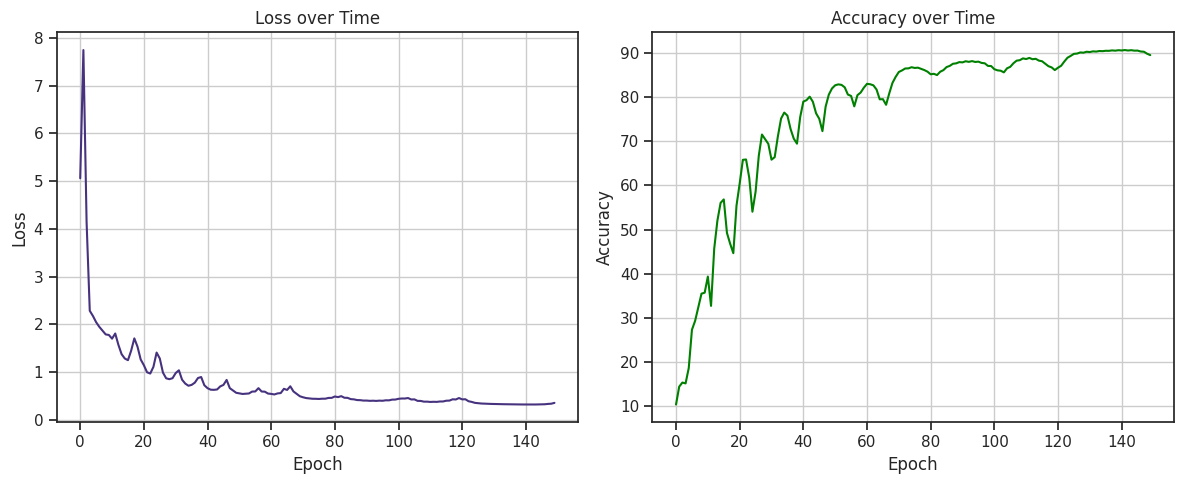

In [18]:
# Plot loss and accuracy over training epochs
epochs = range(len(losses))

plt.figure(figsize=(12,5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs, losses, label='Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Time")
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, label='Accuracy', color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Time")
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluation
Once the network has been trained and we're happy with the accuracy, it's time to measure how well what it has learn generalises to unseen data - the test set. Here we'll calculate accuracy of the network on the test set, and visualise performance using a confusion matrix. A confusion matrix shows us where the network performs well and predicts a label that is the same as the true label of the image (diagnoal cells) and the off-diagonal cells show us where the network gets confused and misclassifies digits.

In [19]:
def make_predictions(X):
    _, output = forward_prop(params, X)
    return output

def get_predictions(output):
    return np.argmax(output, axis=0)

def get_accuracy(predictions, Y):
    return np.mean(predictions == Y)

output = make_predictions(X_test)
predictions = get_predictions(output)
accuracy = get_accuracy(predictions, y_test)

print(f'Accuracy on the test set: {accuracy * 100:.2f}%')

Accuracy on the test set: 89.23%


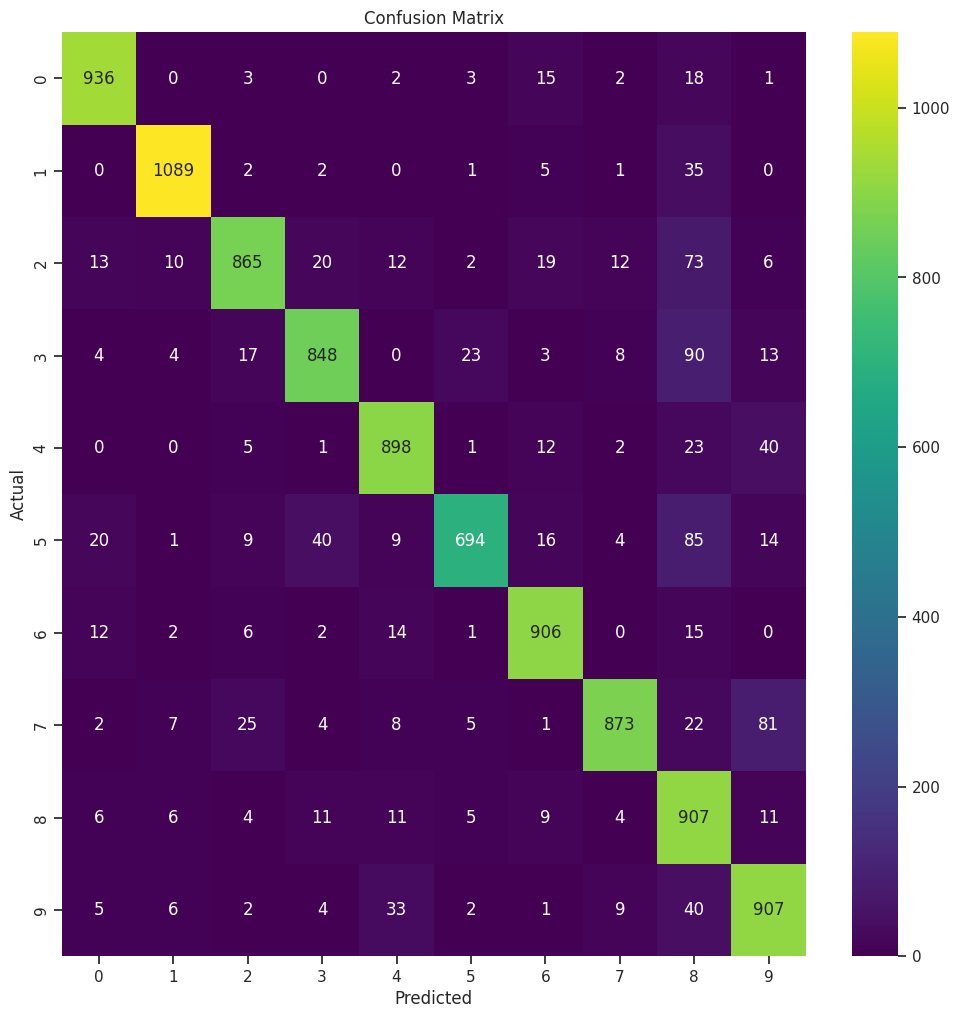

<Figure size 640x480 with 0 Axes>

In [20]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(12, 12))
sns.heatmap(confusion_matrix(y_test, predictions), cmap='viridis', annot=True, fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plt.savefig('confusion.png')

## 8. Wrap Up
- Refactor code to modules
- Comparison with Pytorch/ Tensorflow